# Market Basket Analysis

## Project and Data Description

## Project Overview
Market Basket Analysis: Uncovering Product Associations in Online Retail

This project analyzes transactional data from a UK-based online gift retailer to uncover patterns in customer purchasing behavior. Using association rule mining (the Apriori algorithm), the goal is to identify which products are frequently purchased together, and translate those patterns into actionable recommendations for product bundling, cross-selling, and store/catalog layout.

## About the Dataset

The dataset contains transaction-level records of all purchases made through the retailer's online store. Each row represents a single line item within a transaction, and together these records form a complete picture of customer buying activity over the period covered. The key fields are:
- InvoiceNo — a unique identifier for each transaction, allowing individual purchases to be grouped and distinguished from one another.
- InvoiceDate — the date and time of the transaction, useful for identifying purchasing trends over time.
- StockCode — a unique alphanumeric code assigned to each product.
- Description — a short text description of the product.
- Quantity — the number of units of a product purchased in that transaction.
- UnitPrice — the price per unit, used for revenue-related calculations.
- CustomerID — a unique identifier for the customer (where available).
- Country — the country in which the transaction was made, enabling geographic segmentation.

## Business Question

Which products tend to be purchased together, and how can these associations be used to improve cross-selling, product bundling, and recommendation strategies?

More specifically, this analysis aims to answer:

1. What are the most frequently co-purchased product combinations?
2. Which association rules have the strongest lift and confidence, indicating genuinely meaningful (not just coincidental) relationships?
3. How can these insights inform decisions such as product placement, bundle promotions, or "customers who bought this also bought..." recommendations?

In [1]:
#install mlxtend
!pip install mlxtend

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules
import textwrap

## Importing and Cleaning Data

In [3]:
#importing functions to clean data
from python_tools import load_data, inspect_data

# creating path,loading and inspecting the data
path = './data/online_retail.csv'
df = load_data(path)
inspect_data(df)

------- HEAD -------
   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

 ------- SHAPE -------
(527918, 8)

 ------- INFO -------
<class 'pandas.DataFrame'>
RangeIndex: 527918 entries, 0 to 527917
Data columns (total 8 columns)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
527913,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
527914,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
527915,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
527916,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
'''
Clean data through chaining. Tp achieve:
1. Change invoice date to date format
2. Drop all entries with less than 0 quantity and price
3. Drop all cancled invoices
4. Drop all entries where the stockcode is a pure string
5. Assign the most frequent description to the stockcode
6. remove all the leading and trailing spaces in the stockcode and description
'''

df_cleansed = (
    df
    .assign(
        InvoiceNo = lambda x: x['InvoiceNo'].astype('string').str.strip(),
        StockCode = lambda x: x['StockCode'].str.strip(),#removes the leading or trailing spaces
        Description = lambda x: x['Description'].str.strip(),
        InvoiceDate = lambda x: pd.to_datetime(x['InvoiceDate']), #converts the InvoiceDate to date data type
    )
    .query('Quantity > 0 and UnitPrice > 0') #dropping entries with less than 1 quantity and price
    .loc[lambda x: ~x["InvoiceNo"].str.startswith("C")] #dropping all invoices that start with C
    .loc[
        lambda x: ~x['StockCode'].str.fullmatch(r'[A-Za-z]+') #drops all the entries where stockcode is just a pure letters
    ]
    .assign(
        Description = lambda x: x['StockCode'].map(x.groupby('StockCode')['Description'].agg(
            lambda s:s.mode().iloc[0] if not s.mode().empty else np.nan)) #assigns the most common description to the stockcode
    )
)

In [5]:
# inspect the new data
inspect_data(df_cleansed)

------- HEAD -------
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

 ------- SHAPE -------
(527918, 8)

 ------- INFO -------
<class 'pandas.DataFrame'>
RangeIndex: 527918 entries, 0 to 527917
Data columns (total 8 columns):
 #   Colum

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
527913,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
527914,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
527915,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
527916,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
df_cleansed.duplicated(subset = ['InvoiceNo','StockCode']).sum()

np.int64(10470)

In [7]:
df_cleansed.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
527913,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
527914,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
527915,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
527916,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [8]:
# save the cleaned data as a csv
df_cleansed.to_csv('./data/online_retail.csv', index = False)

## Explotarory Data Analysis

In [9]:
df_cleansed.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,527918.000000,527918,527918.000000,396482.000000
mean,10.564506,2011-07-04 21:31:06.652396,3.279178,15301.437256
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:23:00,1.250000,13975.000000
50%,3.000000,2011-07-20 13:26:00,2.080000,15159.000000
75%,11.000000,2011-10-19 13:38:00,4.130000,16801.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,155.810892,NaN,4.449212,1709.762964


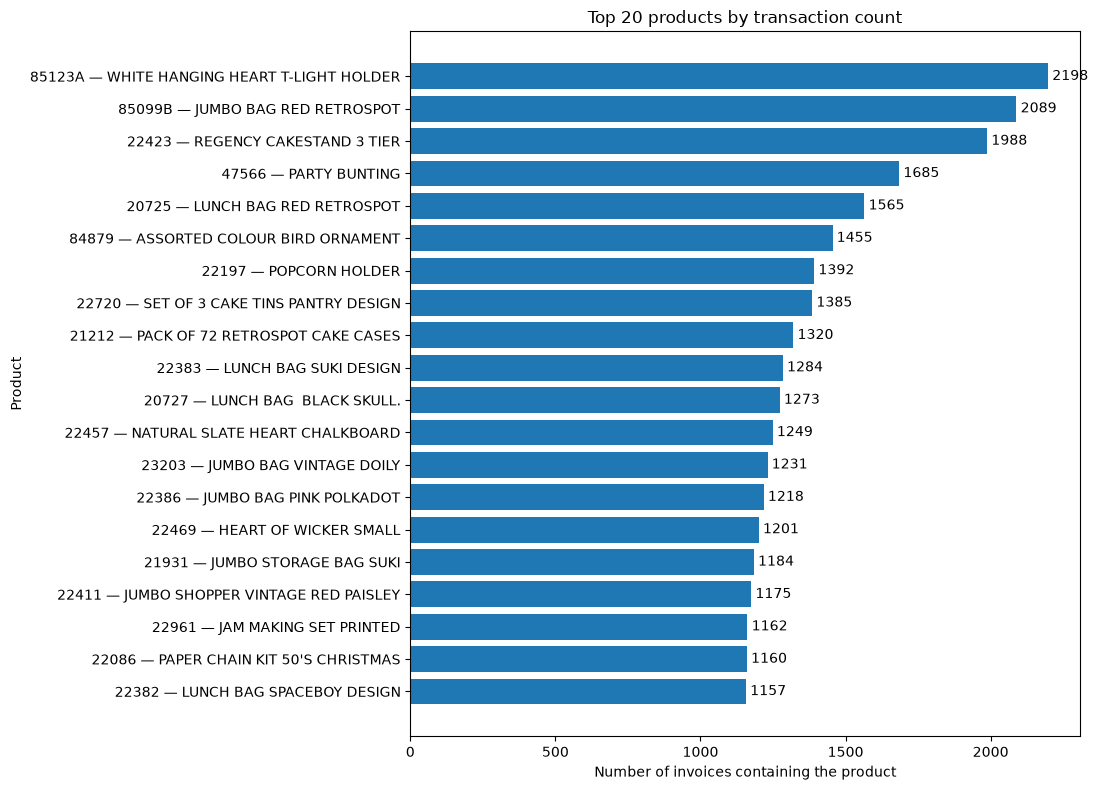

In [10]:
#the top  bought products
product_transactions = (
    df_cleansed.groupby(["StockCode", "Description"])["InvoiceNo"]
    .nunique()
    .rename("TransactionCount")
    .reset_index()
    .sort_values("TransactionCount", ascending=False)
)

# visualizing using a horizontal bar chart
top_n = 20
top_products = product_transactions.head(top_n).sort_values("TransactionCount")

labels = (
    top_products["StockCode"].astype(str)
    + " — "
    + top_products["Description"].fillna("No description")
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(labels, top_products["TransactionCount"])
ax.bar_label(bars, padding=3, fmt="%d")

ax.set_xlabel("Number of invoices containing the product")
ax.set_ylabel("Product")
ax.set_title(f"Top {top_n} products by transaction count")
fig.tight_layout()
plt.show()

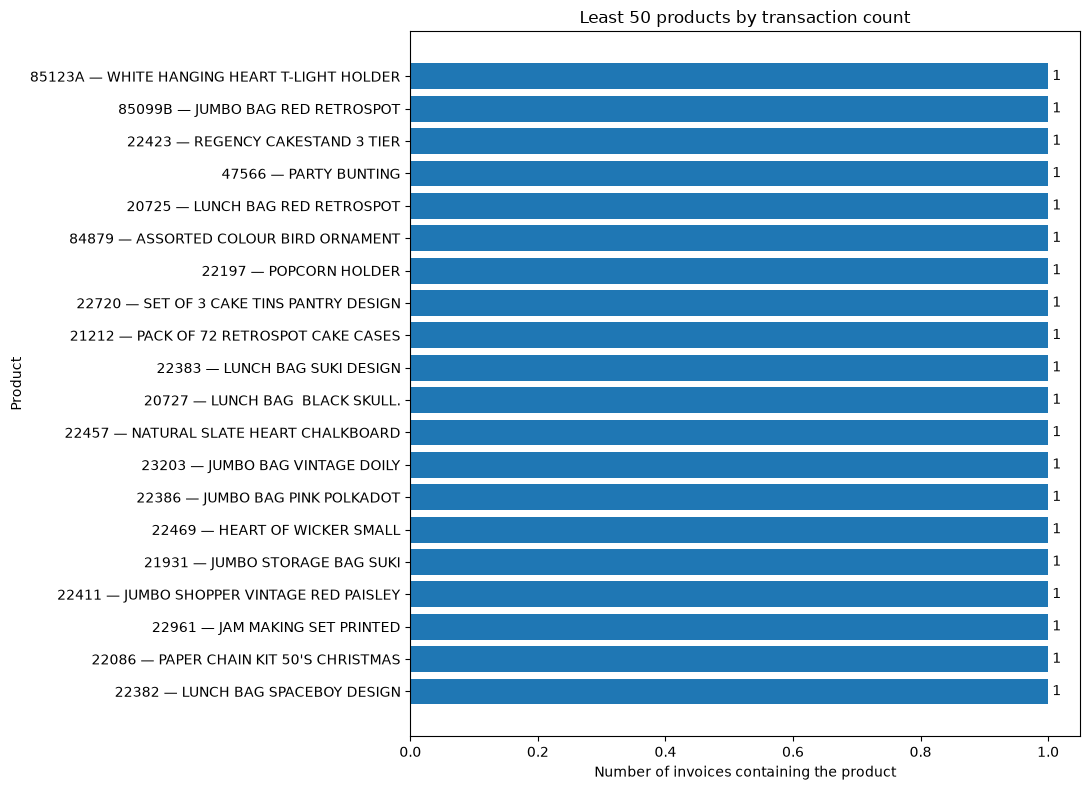

In [11]:
#visualizing the bottom least purchases

bottom_n = 50
bottom_products = product_transactions.tail(top_n).sort_values("TransactionCount")
fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(labels, bottom_products["TransactionCount"])
ax.bar_label(bars, padding=3, fmt="%d")

ax.set_xlabel("Number of invoices containing the product")
ax.set_ylabel("Product")
ax.set_title(f"Least {bottom_n} products by transaction count")
fig.tight_layout()
plt.show()

In [12]:
#getting the number of transactions by country
country_transactions = (
    df_cleansed.groupby('Country')['InvoiceNo']
    .count()
    .rename('TransactionsCount')
    .sort_values(ascending = False)
)
print(country_transactions)

Country
United Kingdom          484053
Germany                   8658
France                    8102
EIRE                      7885
Spain                     2422
Netherlands               2322
Switzerland               1935
Belgium                   1935
Portugal                  1464
Australia                 1181
Norway                    1048
Channel Islands            747
Italy                      741
Finland                    647
Cyprus                     612
Unspecified                446
Sweden                     428
Austria                    384
Denmark                    367
Poland                     325
Japan                      321
Israel                     295
Hong Kong                  279
Singapore                  215
Iceland                    182
USA                        179
Canada                     150
Greece                     142
Malta                      109
United Arab Emirates        67
European Community          57
RSA                         57


## Market Basket Analysis

In [13]:
#preparing the data
UK_df = df_cleansed[df_cleansed['Country'] == 'United Kingdom'] #getting the UK data
transactions = UK_df.groupby('InvoiceNo')['Description'].agg(lambda x: list(set(x))).tolist() #creating list of lists
encoder = TransactionEncoder().fit(transactions) #initiating the TransactionEncoder and fiting transactions
onehot = encoder.transform(transactions) #constructing an array of onehot encoded transactions
onehot = pd.DataFrame(onehot,columns = encoder.columns_) #converting to a dataframe
print(onehot)
print(onehot.mean())

       *Boombox Ipod Classic  *USB Office Mirror Ball  10 COLOUR SPACEBOY PEN  \
0                      False                    False                   False   
1                      False                    False                   False   
2                      False                    False                   False   
3                      False                    False                   False   
4                      False                    False                   False   
...                      ...                      ...                     ...   
17907                  False                    False                   False   
17908                  False                    False                   False   
17909                  False                    False                   False   
17910                  False                    False                   False   
17911                  False                    False                   False   

       12 COLOURED PARTY BA

In [14]:
#data mining
frequent_itemsets = apriori(onehot, use_colnames = True,min_support = 0.01)
rules = association_rules(frequent_itemsets)

### Defination of support,confidence and lift
* Support - measures how frequently an item or itemset appears in the entire dataset.
        *It tells us how popular an itemset is among all transactions.
* Confidence - measures how often item B is purchased when item A is purchased.
            * It tells us how reliable the association rule is.
            * For example, a confidence of 0.80 means that 80% of transactions containing A also contain B.
* Lift - measures how much more likely item B is to be purchased when item A is purchased compared with B being purchased independently.
    * It helps determine whether the relationship between A and B is meaningful or simply due to B being popular.
    * Lift > 1: A and B are positively associated; purchasing A increases the likelihood of purchasing B.
    * Lift = 1: A and B are independent; there is no meaningful association.
    * Lift < 1: A and B are negatively associated; purchasing A decreases the likelihood of purchasing B.

In [15]:
print(rules)
print(len(rules))

                                           antecedents  \
0          frozenset({PINK REGENCY TEACUP AND SAUCER})   
1                       frozenset({HERB MARKER BASIL})   
2                        frozenset({HERB MARKER MINT})   
3                     frozenset({HERB MARKER PARSLEY})   
4                       frozenset({HERB MARKER BASIL})   
..                                                 ...   
176  frozenset({LUNCH BAG SUKI DESIGN, LUNCH BAG PI...   
177  frozenset({WOODLAND CHARLOTTE BAG, CHARLOTTE B...   
178  frozenset({WOODLAND CHARLOTTE BAG, CHARLOTTE B...   
179  frozenset({RED RETROSPOT CHARLOTTE BAG, CHARLO...   
180  frozenset({WOODLAND CHARLOTTE BAG, RED RETROSP...   

                                      consequents  antecedent support  \
0    frozenset({GREEN REGENCY TEACUP AND SAUCER})            0.039192   
1                   frozenset({HERB MARKER MINT})            0.012952   
2                  frozenset({HERB MARKER BASIL})            0.013008   
3          

In [16]:
#breaking down the 181 rules to have only single rules
rules['itemset'] = rules.apply(lambda r: frozenset(r['antecedents'] | r['consequents']), axis=1)
unique_rules = (rules.sort_values(['confidence', 'lift'], ascending=False)
                     .drop_duplicates('itemset'))
print(len(unique_rules))

94


In [17]:
# making the rules readable
display_rules = (
    unique_rules
    .assign(
        antecedents = lambda x: x['antecedents'].apply(lambda i: ', '.join(sorted(i))),
        consequents = lambda x: x['consequents'].apply(lambda i: ', '.join(sorted(i))),
    )
    .loc[:, ['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    .sort_values('lift', ascending=False)
    .assign(
        support = lambda x: (x['support'] * 100).round(2).astype(str) + '%',
        confidence = lambda x: (x['confidence'] * 100).round(2).astype(str) + '%',
        lift = lambda x: x['lift'].round(2),
    )
    .rename(columns={
        'antecedents': 'If a customer buys',
        'consequents': 'They also tend to buy',
        'support': 'Support (% of all orders)',
        'confidence': 'Confidence (% of the time)',
        'lift': 'Lift (strength of association)'
    })
)

display_rules.head(44)

,If a customer buys,They also tend to buy,Support (% of all orders),Confidence (% of the time),Lift (strength of association)
144,"HERB MARKER BASIL, HERB MARKER PARSLEY, HERB M...",HERB MARKER THYME,1.0%,96.26%,74.96
155,"HERB MARKER MINT, HERB MARKER PARSLEY, HERB MA...",HERB MARKER ROSEMARY,1.0%,95.74%,74.24
101,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY",HERB MARKER THYME,1.1%,95.17%,74.12
96,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER ROSEMARY,1.07%,95.5%,74.05
89,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER PARSLEY,1.05%,94.0%,73.85
78,"HERB MARKER BASIL, HERB MARKER THYME",HERB MARKER ROSEMARY,1.08%,95.07%,73.72
83,"HERB MARKER MINT, HERB MARKER ROSEMARY",HERB MARKER PARSLEY,1.06%,92.2%,72.43
11,HERB MARKER CHIVES,HERB MARKER PARSLEY,1.04%,92.12%,72.37
71,"HERB MARKER BASIL, HERB MARKER THYME",HERB MARKER PARSLEY,1.04%,92.12%,72.37
26,HERB MARKER THYME,HERB MARKER ROSEMARY,1.19%,93.04%,72.15


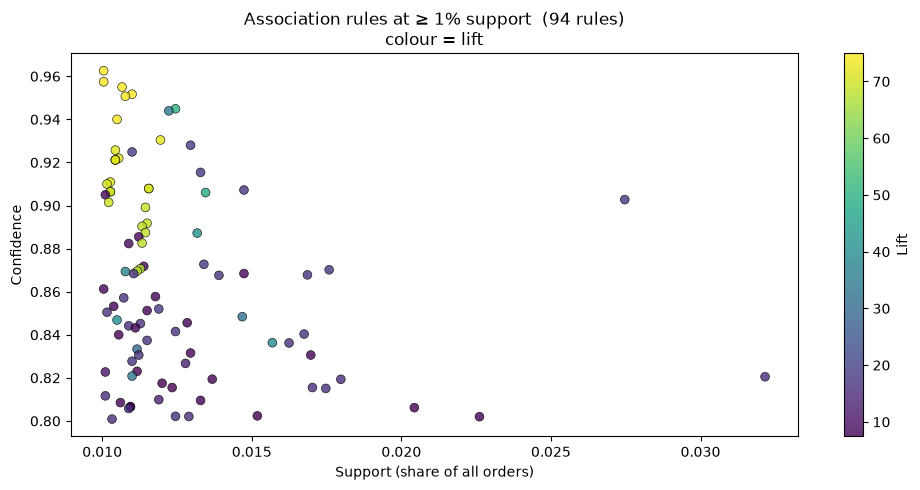

In [18]:
#visualizing the 94 rules using a scatter plot
def plot_rules(rules_df, title, key=False, dot_size=60):
    df = rules_df.copy().reset_index(drop=True)
    df['rule'] = (
        df['antecedents'].apply(lambda s: ', '.join(sorted(s)))
        + '  →  '
        + df['consequents'].apply(lambda s: ', '.join(sorted(s)))
    )

    if key:
        # chart on top, key underneath
        fig, (ax, kax) = plt.subplots(
            2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [3, 1.3]}
        )
        kax.axis('off')
    else:
        fig, ax = plt.subplots(figsize=(10, 5))

    sc = ax.scatter(
        df['support'], df['confidence'],
        s=dot_size, c=df['lift'], cmap='viridis',
        alpha=0.8, edgecolors='black', linewidths=0.5
    )
    ax.set_xlabel('Support (share of all orders)')
    ax.set_ylabel('Confidence')
    ax.set_title(f'{title}  ({len(df)} rules)\ncolour = lift')
    ax.grid(False)                      # no background grid
    plt.colorbar(sc, ax=ax, label='Lift')

    if key:
        # number each dot
        for i, r in df.iterrows():
            ax.annotate(
                str(i + 1), (r['support'], r['confidence']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, fontweight='bold'
            )
        # key listing what each number means
        key_text = '\n'.join(
            textwrap.fill(f"{i + 1}.  {r['rule']}", width=105,
                          subsequent_indent='      ')
            for i, r in df.iterrows()
        )
        kax.text(0, 1, 'Key', fontsize=10, fontweight='bold', va='top')
        kax.text(0, 0.88, key_text, fontsize=9, va='top')

    plt.tight_layout()
    plt.show()

# Plot of the 94 rules
plot_rules(unique_rules[unique_rules['support'] >= 0.01],
           'Association rules at ≥ 1% support', dot_size=40)

In [19]:
#breaking down the 94 rules into families
family_kw = {
    'Herb markers':       'HERB MARKER',
    'Regency teacups':    'REGENCY TEACUP',
    'Regency tea plates': 'REGENCY TEA PLATE',
    'Jumbo bags':         'JUMBO',
    'Charlotte bags':     'CHARLOTTE BAG',
    'Christmas wooden':   'CHRISTMAS SCANDINAVIAN',
    "Poppy's Playhouse":  "POPPY'S PLAYHOUSE",
    'Sweets bowls':       'SMALL CHOCOLATES|SMALL MARSHMALLOWS|SMALL DOLLY MIX',
    'Paper party ware':   'PAPER NAPKINS|PAPER PLATES',
}

unique_rules['items_text'] = unique_rules['itemset'].apply(lambda s: ' | '.join(s))

def tag_family(text):
    for fam, kw in family_kw.items():
        if pd.Series([text]).str.contains(kw, case=False).iloc[0]:
            return fam
    return 'Other'

unique_rules['family'] = unique_rules['items_text'].apply(tag_family)

family_summary = (unique_rules.groupby('family')
    .agg(rules=('lift', 'size'),
         avg_confidence=('confidence', 'mean'),
         avg_lift=('lift', 'mean'),
         max_support=('support', 'max'))
    .sort_values('avg_lift', ascending=False).round(3))
print(family_summary)

                    rules  avg_confidence  avg_lift  max_support
family                                                          
Herb markers           26           0.915    71.055        0.012
Regency tea plates      4           0.894    44.925        0.016
Poppy's Playhouse       1           0.847    40.450        0.010
Paper party ware        1           0.869    37.254        0.011
Christmas wooden        2           0.896    33.512        0.015
Sweets bowls            2           0.827    31.730        0.011
Charlotte bags         23           0.845    16.861        0.018
Regency teacups         7           0.862    16.514        0.032
Other                   1           0.823    10.587        0.010
Jumbo bags             27           0.836     8.140        0.023


In [20]:
#filtering to rules that occur atlist 2% of the transaction
filtered_rules = unique_rules[unique_rules['support'] >= 0.02]
print(len(filtered_rules))
print(filtered_rules)

4
                                           antecedents  \
50   frozenset({ROSES REGENCY TEACUP AND SAUCER, PI...   
0          frozenset({PINK REGENCY TEACUP AND SAUCER})   
113  frozenset({JUMBO BAG PINK POLKADOT, JUMBO SHOP...   
114  frozenset({JUMBO BAG PINK POLKADOT, JUMBO STOR...   

                                      consequents  antecedent support  \
50   frozenset({GREEN REGENCY TEACUP AND SAUCER})            0.030427   
0    frozenset({GREEN REGENCY TEACUP AND SAUCER})            0.039192   
113          frozenset({JUMBO BAG RED RETROSPOT})            0.025346   
114          frozenset({JUMBO BAG RED RETROSPOT})            0.028193   

     consequent support   support  confidence       lift  representativity  \
50             0.052032  0.027468    0.902752  17.349892               1.0   
0              0.052032  0.032157    0.820513  15.769341               1.0   
113            0.108028  0.020433    0.806167   7.462569               1.0   
114            0.108028  0.02

In [21]:
filtered_rules_display = (
    filtered_rules
    .assign(
        antecedents = lambda x: x['antecedents'].apply(lambda i: ', '.join(sorted(i))),
        consequents = lambda x: x['consequents'].apply(lambda i: ', '.join(sorted(i))),
    )
    .loc[:, ['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    .sort_values('lift', ascending=False)
    .assign(
        support = lambda x: (x['support'] * 100).round(2).astype(str) + '%',
        confidence = lambda x: (x['confidence'] * 100).round(2).astype(str) + '%',
        lift = lambda x: x['lift'].round(2),
    )
    .rename(columns={
        'antecedents': 'If a customer buys',
        'consequents': 'They also tend to buy',
        'support': 'Support (% of all orders)',
        'confidence': 'Confidence (% of the time)',
        'lift': 'Lift (strength of association)'
    })
)
filtered_rules_display

,If a customer buys,They also tend to buy,Support (% of all orders),Confidence (% of the time),Lift (strength of association)
50,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,2.75%,90.28%,17.35
0,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.22%,82.05%,15.77
113,"JUMBO BAG PINK POLKADOT, JUMBO SHOPPER VINTAGE...",JUMBO BAG RED RETROSPOT,2.04%,80.62%,7.46
114,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,2.26%,80.2%,7.42


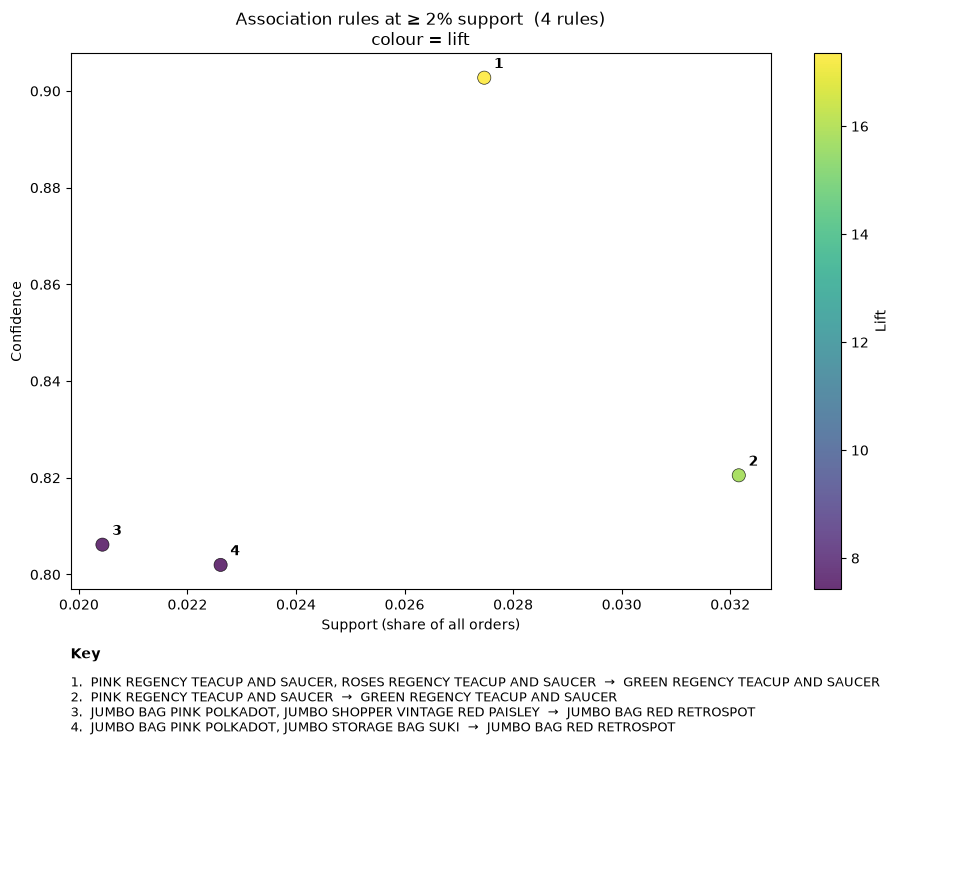

In [22]:
# Plot 2: the 5 rules, numbered with a key underneath
plot_rules(unique_rules[unique_rules['support'] >= 0.02],
           'Association rules at ≥ 2% support', key=True, dot_size=90)

Data duration is 373 days 04:23:00


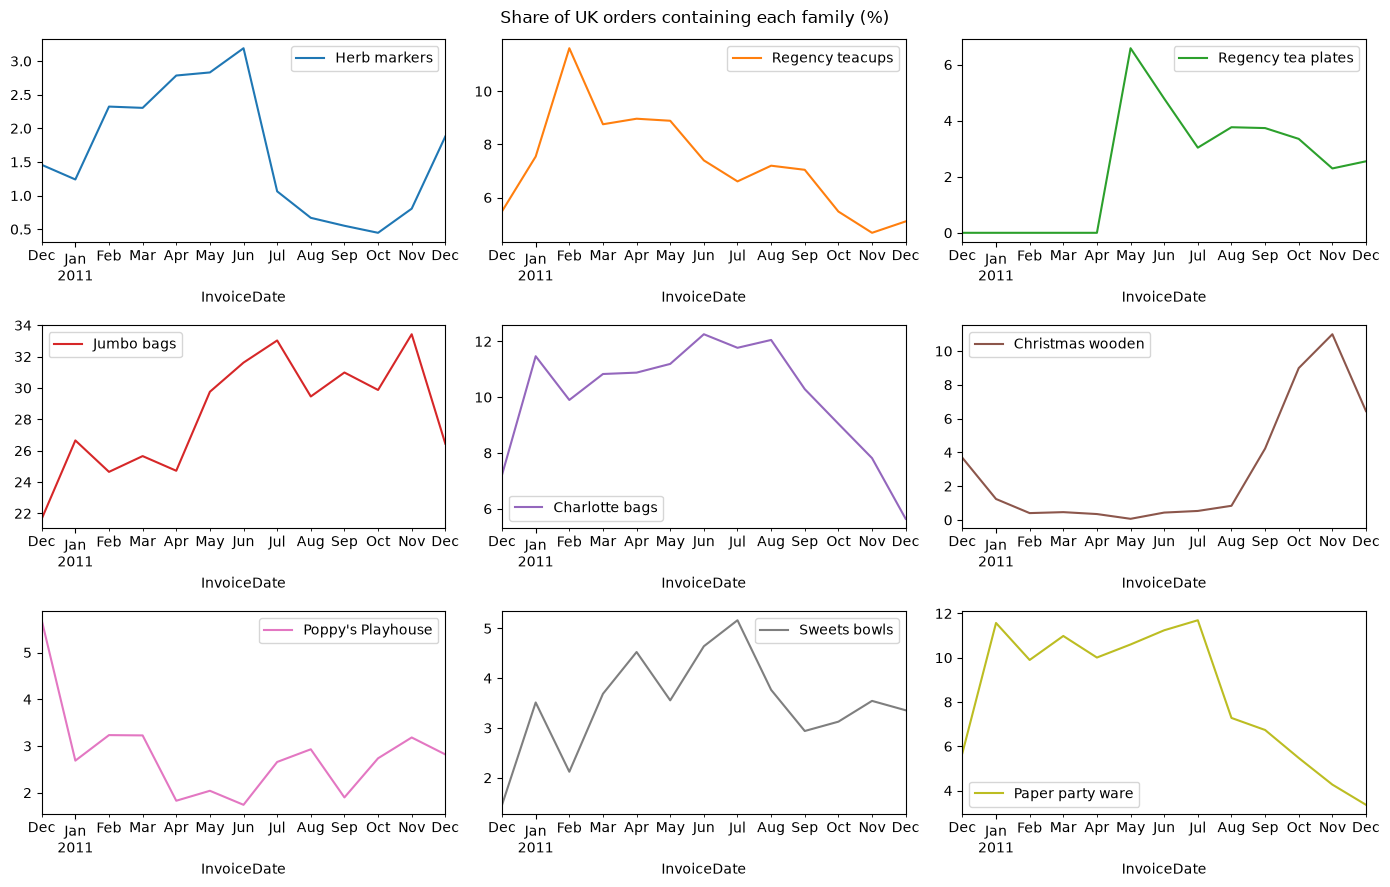

In [23]:
#checking if any of the families are seasonal
time_range = UK_df['InvoiceDate'].max() - UK_df['InvoiceDate'].min()
print(f"Data duration is {time_range}")
monthly_all = UK_df.groupby(UK_df['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique()

season = {}
for fam, kw in family_kw.items():
    sub = UK_df[UK_df['Description'].str.contains(kw, case=False, na=False)]
    monthly = sub.groupby(sub['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique()
    season[fam] = monthly.div(monthly_all).fillna(0) * 100

season = pd.DataFrame(season)
season.index = season.index.to_timestamp()
season.plot(subplots=True, layout=(3, 3), figsize=(14, 9), sharex=False, legend= True,
            title='Share of UK orders containing each family (%)')
plt.tight_layout(); plt.show()

In [24]:
onehot.mean().sort_values(ascending=False).head(20)

WHITE HANGING HEART T-LIGHT HOLDER    0.121204
JUMBO BAG RED RETROSPOT               0.108028
REGENCY CAKESTAND 3 TIER              0.094071
PARTY BUNTING                         0.088935
LUNCH BAG RED RETROSPOT               0.077713
ASSORTED COLOUR BIRD ORNAMENT         0.076541
POPCORN HOLDER                        0.072354
SET OF 3 CAKE TINS PANTRY DESIGN      0.069283
NATURAL SLATE HEART CHALKBOARD        0.068055
LUNCH BAG  BLACK SKULL.               0.067887
LUNCH BAG SUKI DESIGN                 0.066994
HEART OF WICKER SMALL                 0.064984
JUMBO BAG PINK POLKADOT               0.064705
JUMBO SHOPPER VINTAGE RED PAISLEY     0.063254
JUMBO BAG VINTAGE DOILY               0.063254
JUMBO STORAGE BAG SUKI                0.063086
PACK OF 72 RETROSPOT CAKE CASES       0.063030
PAPER CHAIN KIT 50'S CHRISTMAS        0.062807
WOODEN PICTURE FRAME WHITE FINISH     0.060071
LUNCH BAG CARS BLUE                   0.059457
dtype: float64

In [25]:
#estimated opportunity from the top rules
def attach_opportunity(antecedents, consequent, rates=(0.05, 0.10, 0.20)):
    baskets = UK_df.groupby('InvoiceNo')['Description'].agg(set)
    with_a  = baskets[baskets.apply(lambda s: set(antecedents) <= s)]
    missed  = with_a[~with_a.apply(lambda s: consequent in s)]

    b_lines = UK_df[UK_df['Description'] == consequent]
    typical = (b_lines['Quantity'] * b_lines['UnitPrice']).median()  # median resists wholesale outliers

    out = pd.DataFrame({'conversion_rate': rates,
                        'extra_orders': [round(len(missed) * r) for r in rates]})
    out['extra_revenue_£'] = (out['extra_orders'] * typical).round(0)
    print(f"{len(with_a)} orders had the antecedents; {len(missed)} lacked {consequent}; "
          f"typical line value £{typical:.2f}")
    return out

attach_opportunity(['PINK REGENCY TEACUP AND SAUCER'], 'GREEN REGENCY TEACUP AND SAUCER')

702 orders had the antecedents; 126 lacked GREEN REGENCY TEACUP AND SAUCER; typical line value £17.70


,conversion_rate,extra_orders,extra_revenue_£
0,0.05,6,106.0
1,0.10,13,230.0
2,0.20,25,443.0


## Conclusions

This analysis mined 181 association rules from UK orders (Dec 2010 to Dec 2011) at a minimum support of 1% and a minimum confidence of 80%. Many of them were the same itemset written in different directions, so collapsing them left 94 unique rules. These fall into a handful of product families:

| Family | Rules	| Avg confidence | Avg lift | Pattern |
|--------|----------|----------------|----------|---------|
|Herb markers | 26| 92% | 71 | Customers who buy two or three herb markers almost always buy the full set|
|Jumbo bags | 27 | 84%	| 8.1 |	Nearly every rule ends in Jumbo Bag Red Retrospot|
|Charlotte bags | 23 | 85% | 16.9 | Designs combine and end in Red Retrospot Charlotte Bag|
|Regency teacups | 7 | 86% | 16.5 | Pink, Roses and Green teacups bought as a set|
|Regency tea plates | 4 | 89% | 44.9 | Same Pink, Roses, Green pattern as the teacups|
|Other | (Christmas wooden, sweets bowls, Poppy's Playhouse, paper party ware) | 7 | 83% to 90% |	10 to 40 || Smaller sets|

1. Customers buy ranges, not individual products. Almost every strong rule stays inside one product family, and many extend across a shared design theme such as Red Retrospot.

2. The Regency teacup set is the most commercially important pattern. Only five rules survived a 2% support threshold, and three were teacup rules. Customers who buy Pink and Roses teacups buy Green in 90% of cases (2.75% of all orders). Pink alone leads to Green 82% of the time, at the highest support of any rule (3.22%).

3. Green pieces complete the sets. Green is the consequent in the teacup rules and in the tea plate rules. Green teacups appear in only about 5% of orders, so they are not a bestseller that shows up everywhere. They are the piece customers add to finish a set.

4. Jumbo bag rules are strong but less informative. Jumbo Bag Red Retrospot appears in about 11% of all orders, so a high confidence is partly expected. Its lift of 7.4 to 8.4 sits near the ceiling of roughly 9 that this popularity allows.

5. Several families are seasonal. The monthly share of orders shows clear patterns:

* Christmas wooden decorations are close to zero until August, then rise to about 4% in September, 9% in October and 11% in November.
* Herb markers climb from about 1% in winter to a peak of 3.2% in June, then fall to about 0.5% by October.
* Charlotte bags and paper party ware are strongest in summer (11% to 12% of orders) and fall to 3% to 7% by December.

## Recommendations

1. Bundle the sets. Offer the herb marker set, the Regency teacup trio and the tea plate trio as ready-made bundles. Most customers already assemble these sets one item at a time, so a bundle makes it easier to do what they already do.

2. Protect the set-completing items. Keep the Green teacup, the Green tea plate and the Red Retrospot Charlotte and jumbo bags continuously in stock. A stock-out on a completing item can break a set purchase. The data holds no inventory records, so this is an inference to check against stock-out history.

3. Merchandise by range. Create dedicated "Regency", "Jumbo bag" and "Retrospot" sections in the store and on the website. The Red Retrospot print links jumbo bags, Charlotte bags, lunch bags and cake cases, which suggests customers shop by design as well as by product type.

4. Plan stock and promotions around the seasonal calendar.

* Christmas wooden decorations: stock from August and promote from September, ahead of the October to November peak.
* Herb markers: stock in January and February for a February to June peak, and reduce stock from August.
* Charlotte bags and party ware: promote from January through August, and clear stock before the Christmas range takes over.

5. Use the rules for cross-selling. Show "customers also bought" suggestions that use the strongest rules (for example, Pink teacup, then Green teacup). The orders that contain the first item but not the second are the missed opportunities.